In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.vapour_reactor_utils import plot_reactor_solutions

from coupled.vapour_reactor import VapourReactor
from coupled.iso_reactor import Reactor

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30


In [ ]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["Reactor"]["power"]["thermal"] = 15e6
    data["HeatPipe"]["material"]["h_cond"] = 225

In [38]:
Ns = [15, 15, 60]
Ns_coarse = [15, 15, 30]
cfg = generate_config(data, *Ns)
cfg_coarse = generate_config(data, *Ns_coarse)

vap_reactor_coarse = VapourReactor(cfg_coarse)
vap_reactor = VapourReactor(cfg)

vap_reactor.heatpipe.solid.k_temperature = 1100
static_T = 1100

vap_reactor_coarse.set_variable_k(False)
vap_reactor_coarse.set_variable_neutron_data(False)
vap_reactor.set_variable_k(True)
vap_reactor.set_variable_neutron_data(True)

solver = Solver([vap_reactor_coarse, vap_reactor], iterate = True)
solver.fsolve()

Mesh warning: N_Z changed from 60 to 69
Mesh warning: Fuel pin N_Z changed from 27 to 45
Mesh warning: Neutronics N_Z changed from 27 to 45
Mesh warning: N_Z changed from 30 to 23
Mesh warning: Fuel pin N_Z changed from 13 to 15
Mesh warning: Neutronics N_Z changed from 13 to 15
Solving Heat pipe initial values
fsolve message: The solution converged.
final residual L2 norm: 1.495e-06
Running iteration 1 ...
fsolve message: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
final residual L2 norm: 6.954e-01
Running iteration 2 ...


ValueError: VapourReactor encountered an invalid temperature state before neutronics interpolation: T_FP reached a non-physical minimum of -2754.560 K. T_HP=[1790.496, 3038.584], T_FP=[-2754.560, 9744.308], T_v=[2231.526, 2231.545]

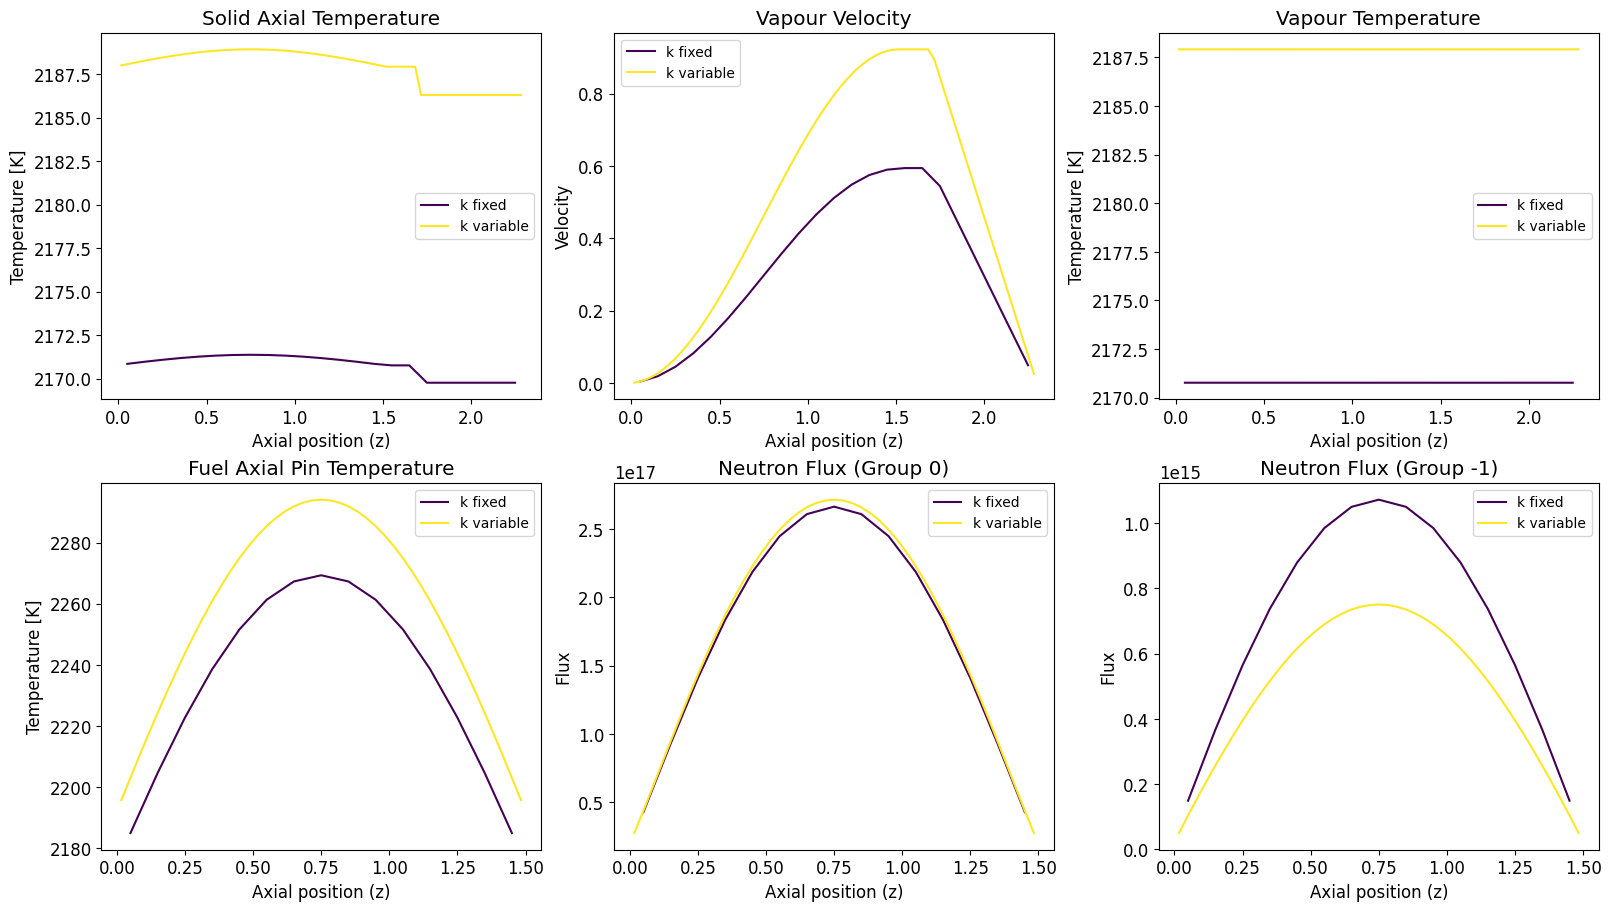

In [ ]:
plot_reactor_solutions(solver)